In [1]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

In [2]:
!pip install scikit-learn

In [3]:
from sklearn.datasets import load_breast_cancer

In [4]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

In [6]:
print(data.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [7]:
X = data.data
y = data.target

In [8]:
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (569, 30)
Shape of y: (569,)


In [9]:
print(data.target_names)

['malignant' 'benign']


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (455, 30)
Testing samples: (114, 30)


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
print(df['target'].value_counts())

target
1    357
0    212
Name: count, dtype: int64


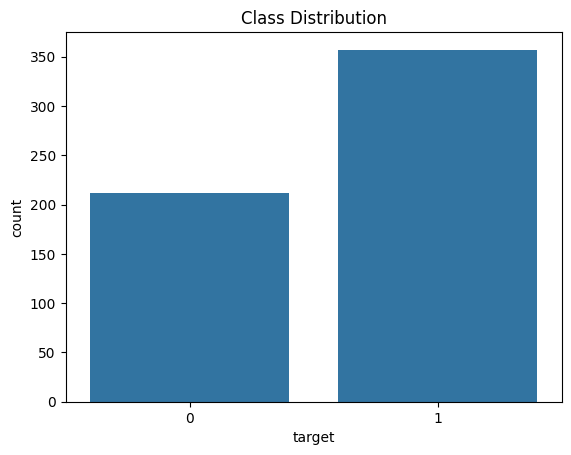

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='target', data=df)
plt.title("Class Distribution")
plt.show()

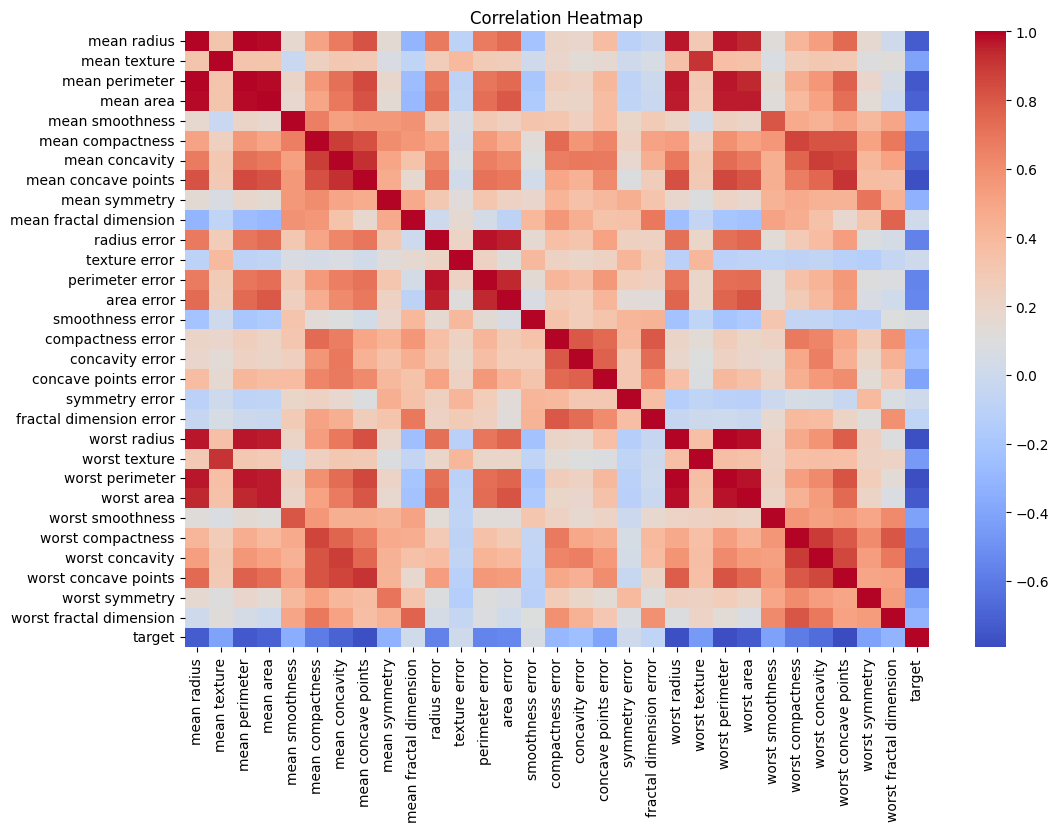

In [15]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

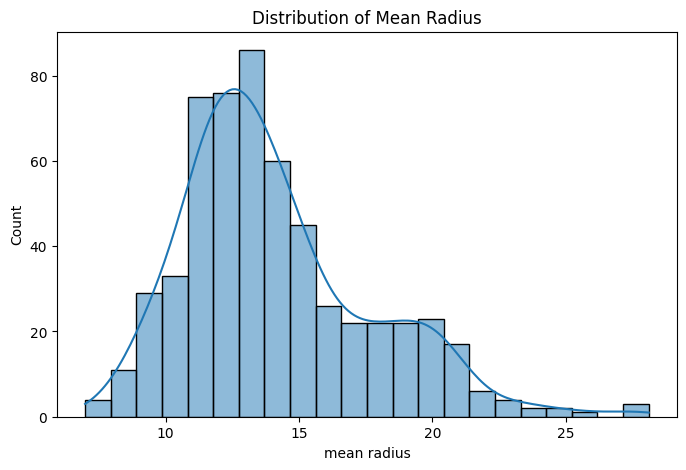

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['mean radius'], kde=True)
plt.title("Distribution of Mean Radius")
plt.show()

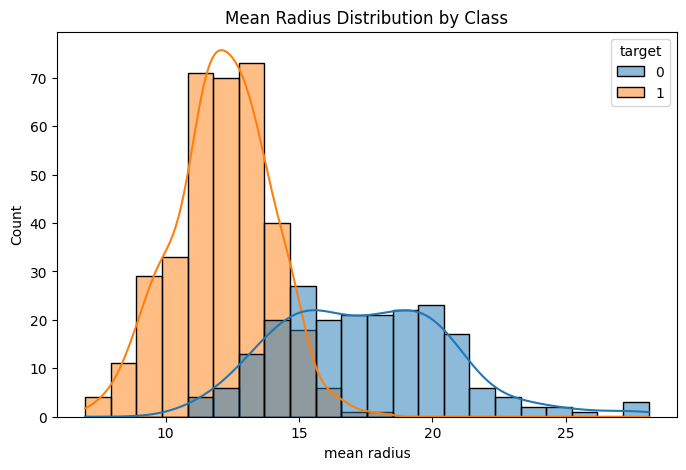

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='mean radius', hue='target', kde=True)
plt.title("Mean Radius Distribution by Class")
plt.show()

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef
)

In [19]:
!pip install xgboost

In [40]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss")
}

In [42]:
results = []

for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    
    results.append([name, acc, auc, precision, recall, f1, mcc])

import pandas as pd

results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "AUC",
    "Precision", "Recall",
    "F1 Score", "MCC"
])

results_df

/home/cloud/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [18:40:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Model,Accuracy,AUC,Precision,Recall,F1 Score,MCC
0,Logistic Regression,0.982456,0.995370,0.986111,0.986111,0.986111,0.962302
1,Decision Tree,0.903509,0.908730,0.955224,0.888889,0.920863,0.801071
2,KNN,0.956140,0.978836,0.958904,0.972222,0.965517,0.905447
3,Naive Bayes,0.929825,0.986772,0.944444,0.944444,0.944444,0.849206
4,Random Forest,0.947368,0.992229,0.958333,0.958333,0.958333,0.886905
5,XGBoost,0.956140,0.990079,0.946667,0.986111,0.965986,0.905824


In [44]:
import pickle

best_model = models["Logistic Regression"]

with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

In [46]:
# Convert scaled test data back to DataFrame
import pandas as pd

feature_names = data.feature_names

# IMPORTANT: Use original unscaled test split
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    data.data, data.target,
    test_size=0.2,
    random_state=42,
    stratify=data.target
)

test_df = pd.DataFrame(X_test_raw, columns=feature_names)
test_df["target"] = y_test_raw

test_df.to_csv("test_data.csv", index=False)

print("test_data.csv saved successfully.")

test_data.csv saved successfully.


In [48]:
!python model_evaluation.py

Confusion Matrix:
[[41  1]
 [ 1 71]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [50]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 125.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 795.4/795.4 kB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 141.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 99.4 MB/s eta 0:00:00
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.11.0
    Uninstalling typing_extensions-4.11.0:
      Successfully uninstalled typing_extensions-4.11.0


In [ ]:
!streamlit run app.py


      👋 Welcome to Streamlit!

      If you'd like to receive helpful onboarding emails, news, offers, promotions,
      and the occasional swag, please enter your email address below. Otherwise,
      leave this field blank.

      Email:  